Project Overview

This project uses a sample insurance dataset downloaded from Kaggle (https://www.kaggle.com/datasets/zainulabaiden/insurance-dataset/data). The primary objective is to perform an exploratory data analysis (EDA) to understand the structure and meaning of the dataset.

The analysis focuses on:

- Exploring the dataset to identify key variables and patterns
- Cleaning and preparing the data for analysis
- Conducting descriptive and exploratory analysis to extract insights

The goal is to gain a clear understanding of the dataset and uncover meaningful information that can support further analysis.

## Loading data and importing the necessary library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv('/Users/Admin/Desktop/insurance.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Data overview

In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


average charges is 13.270$

Key BMI Categories
Underweight: Below 18.5
Normal Weight: 18.5 to 24.9
Overweight: 25.0 to 29.9
Obesity: 30.0 or higher 

In [7]:
#check null value
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Clean data

In [8]:
df_cleaned = df.copy()

In [9]:
#turn smoker into 0 if No and 1 if Yes in the dataframe
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no": 0, "yes":1})

In [10]:
# turn sex into 0 if male and 1 if female
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female":1})

In [11]:
#rename column 'sex' and 'smoker'
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace = True)

In [12]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [13]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [14]:
# turn region into multiple columns, drop the first column as unnecessary
df_cleaned = pd.get_dummies(df_cleaned, columns = ['region'], drop_first=True)

In [15]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [16]:
#turn whole dataset into integer data type
df_cleaned = df_cleaned.astype(int)

In [17]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


## Analysis

<Axes: >

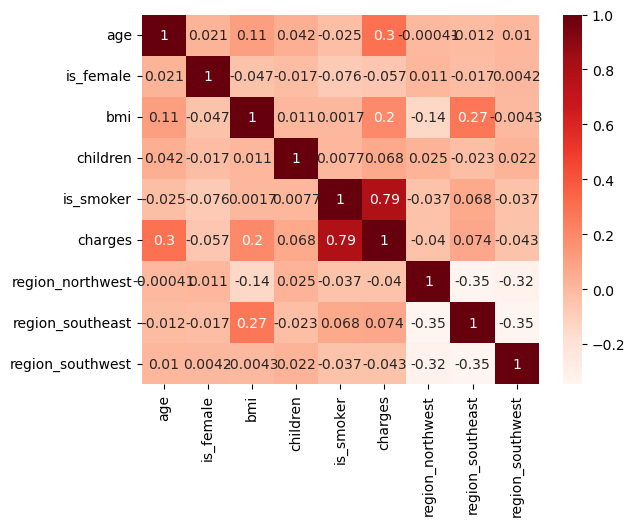

In [18]:
# calculate the correlation matrix on all columns
corr = df_cleaned.corr()

# plot the heatmap
sns.heatmap(corr, cmap="Reds", annot=True)


#### Charges is heavily driven by smoking status (corr = 0.79), suggesting a strong segmentation effect. Other variables like age and BMI have a moderate influence.

In [19]:
overall_mean = df_cleaned['charges'].mean()

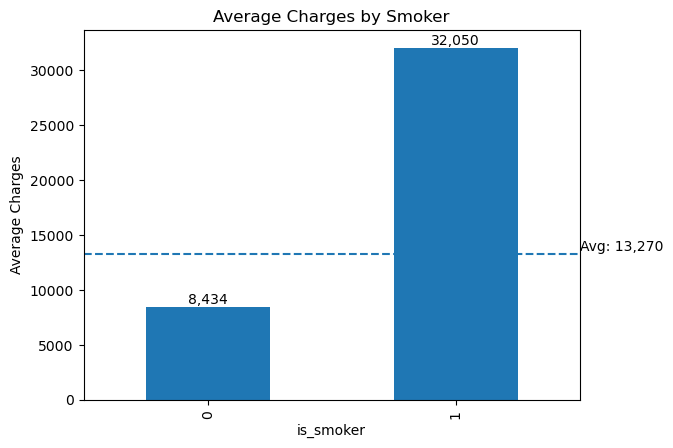

In [20]:
#calculate the average charges for smoker and non_smoker
avg_charges = df_cleaned.groupby('is_smoker', observed=True)['charges'].mean()
#Make the chart
ax = avg_charges.plot(kind='bar')

# Add number above each bar
for i, v in enumerate(avg_charges):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

# Add the average of the charges line
plt.axhline(overall_mean, linestyle='--')

# Add label for the line
plt.text(len(avg_charges)-0.5, overall_mean, f'Avg: {overall_mean:,.0f}', va='bottom')

plt.title('Average Charges by Smoker')
plt.xlabel('is_smoker')
plt.ylabel('Average Charges')
plt.show()

In [21]:
#Add category for BMI based on Key BMI Categories:  Underweight: Below 18.5 Normal Weight: 18.5 to 24.9 Overweight: 25.0 to 29.9 Obesity: 30.0 or higher
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obesity']
)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obesity
2,28,0,33,3,0,4449,0,1,0,Obesity
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


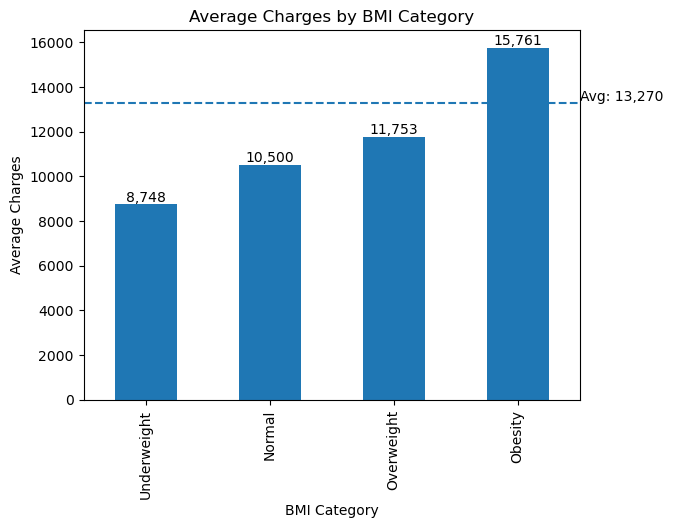

In [22]:
#calculate the average charges for each bmi category
avg_charges = df_cleaned.groupby('bmi_category', observed=True)['charges'].mean()
#Make the chart
ax = avg_charges.plot(kind='bar')

# Add number above each bar
for i, v in enumerate(avg_charges):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

# Add the average of the charges line
plt.axhline(overall_mean, linestyle='--')

# Add label for the line
plt.text(len(avg_charges)-0.5, overall_mean, f'Avg: {overall_mean:,.0f}', va='bottom')

plt.title('Average Charges by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Charges')
plt.show()

In [23]:
#Add category for age group
df_cleaned['age_group'] = pd.cut(
    df_cleaned['age'],
    bins=[0, 25, 35, 45, 55, float('inf')],
    labels=['18 to 25', '26 to 35', '36 to 45', '46 to 55', 'Above 55']
)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category,age_group
0,19,1,27,0,1,16884,0,0,1,Overweight,18 to 25
1,18,0,33,1,0,1725,0,1,0,Obesity,18 to 25
2,28,0,33,3,0,4449,0,1,0,Obesity,26 to 35
3,33,0,22,0,0,21984,1,0,0,Normal,26 to 35
4,32,0,28,0,0,3866,1,0,0,Overweight,26 to 35


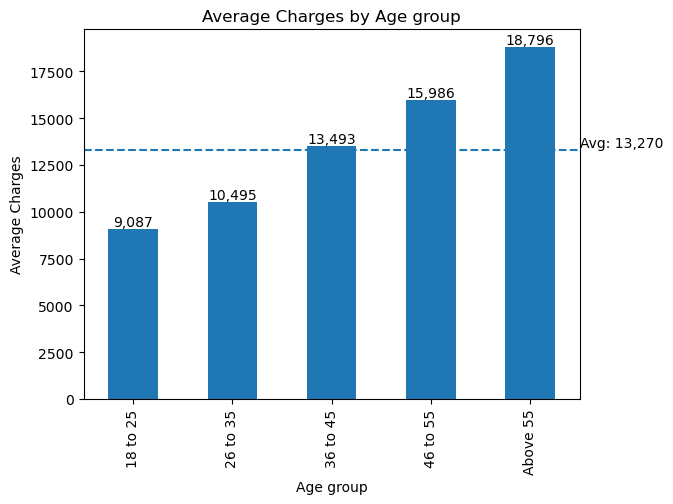

In [24]:
#calculate the average charges for each age group
avg_charges = df_cleaned.groupby('age_group', observed=True)['charges'].mean()
#Make the chart
ax = avg_charges.plot(kind='bar')

# Add number above each bar
for i, v in enumerate(avg_charges):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

# Add the average of the charges line
plt.axhline(overall_mean, linestyle='--')

# Add label for the line
plt.text(len(avg_charges)-0.5, overall_mean, f'Avg: {overall_mean:,.0f}', va='bottom')

plt.title('Average Charges by Age group')
plt.xlabel('Age group')
plt.ylabel('Average Charges')
plt.show()

Key Insights from the Analysis:

- Smoking status, BMI, and age are identified as the primary factors influencing medical charges, showing strong correlations with overall costs.
- Customers with above-average charges are predominantly those who smoke, are over 46 years of age, and fall within the obese category (BMI > 30).
- In contrast, customers with the lowest charges are generally non-smokers, under 35 years old, and classified as underweight (BMI < 18.5).

### High cost and low cost customer analyst

In [25]:
# High cost conditions
high_cost_group = df_cleaned[
    (df_cleaned['is_smoker'] == 1) &
    (df_cleaned['age'] > 46) &
    (df_cleaned['bmi'] > 30)
]

# Low_cost conditions
low_cost_group = df_cleaned[
    (df_cleaned['is_smoker'] == 0) &
    (df_cleaned['age'] < 35) &
    (df_cleaned['bmi'] < 18.5)
]

print("High cost group size:", len(high_cost_group))
print("Low cost group size:", len(low_cost_group))

High cost group size: 44
Low cost group size: 12


/var/folders/s1/pp6vc2js40qbg7b1xs2dq1jc0000gn/T/ipykernel_3865/85506689.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


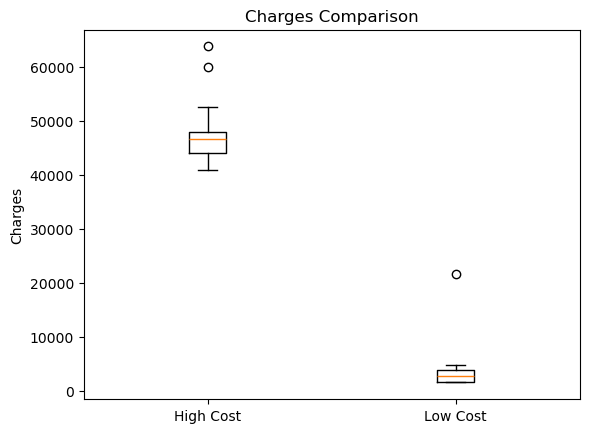

In [26]:
plt.boxplot(
    [high_cost_group['charges'], low_cost_group['charges']],
    labels=['High Cost', 'Low Cost']
)

plt.title('Charges Comparison')
plt.ylabel('Charges')
plt.show()

Given the limited size of the dataset, it is not appropriate to draw definitive conclusions regarding differences in charges across groups based on location or number of children. A larger and more comprehensive dataset would be required to meaningfully explore these relationships. In order to extend this analysis, additional variables should be collected to better understand customer behavior and risk profiles.

Recommended additional data points include:

- Occupation of the customer
- Average daily training or activity hours
- Primary mode of transportation
- Household size (number of family members)
- Lifestyle indicators (e.g., hobbies, daily habits)
- Average hours of sleep
- Historical medical conditions
- Policy payment information (total payment amount, payment type, and payment frequency)
- Policy history for each customer (e.g., claims, renewals, duration of coverage)